# Week 2 - Data Exploration

Project: **Robust Federated Learning Against Adversarial Attacks**

This notebook explores the local CheXpert data stored in `data/`. It documents access requirements, checks data completeness, summarizes label imbalance and missing values, and displays example chest X-ray images.

## Dataset Access and Credentialing

The project uses the Stanford CheXpert small chest X-ray dataset. The official access page is: https://stanfordmlgroup.github.io/competitions/chexpert/

Credentialing procedure:

1. Visit the official CheXpert page.
2. Accept the dataset terms of use and complete the Stanford access form if prompted.
3. Download `CheXpert-v1.0-small` and place it under `data/raw/`.
4. Place the metadata CSV at `data/raw/train.csv`.

The current repository already contains `data/raw/train.csv` and `data/raw/CheXpert-v1.0-small/train/`, so no additional credentials are needed to rerun this notebook locally.

In [19]:
from pathlib import Path
import re

from IPython import get_ipython
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 120
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / 'data' / 'raw' / 'train.csv').exists():
            return path
    raise FileNotFoundError('Could not find data/raw/train.csv from the current directory.')

ROOT = find_project_root()
RAW_DIR = ROOT / 'data' / 'raw'
CSV_PATH = RAW_DIR / 'train.csv'
LABELS = ['Cardiomegaly', 'Edema', 'Consolidation', 'Atelectasis', 'Pleural Effusion']

df = pd.read_csv(CSV_PATH)
df.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [20]:
summary = {
    'rows': len(df),
    'columns': len(df.columns),
    'patients': df['Path'].str.extract(r'patient(\d+)')[0].nunique(),
    'frontal_images': int((df['Frontal/Lateral'] == 'Frontal').sum()),
    'lateral_images': int((df['Frontal/Lateral'] == 'Lateral').sum()),
}
summary

{'rows': 223414,
 'columns': 19,
 'patients': 64540,
 'frontal_images': 191027,
 'lateral_images': 32387}

## Descriptive Statistics

CheXpert is a multi-label imaging dataset. The labels contain positive `1`, negative `0`, uncertain `-1`, and missing values. For this incremental Week 2 work, uncertain values and missing values are mapped to `0` so that a first standalone baseline can be trained.

,Age
count,223414.000000
mean,60.430653
std,17.820925
min,0.000000
25%,49.000000
50%,62.000000
75%,74.000000
max,90.000000


,count
Sex,
Male,132636
Female,90777
Unknown,1


,count
View,
Frontal,191027
Lateral,32387


,count
Projection,
AP,161590
NaN,32387
PA,29420
LL,16
RL,1


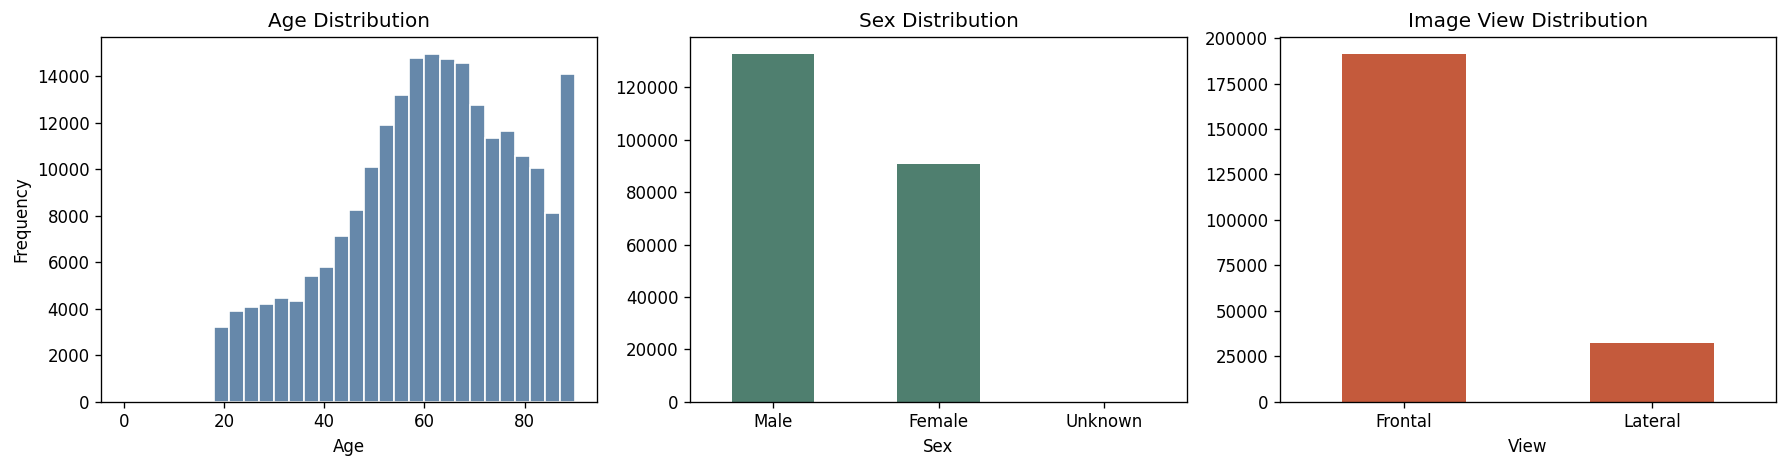

In [23]:
display(df[['Age']].describe())
sex_counts = df['Sex'].value_counts(dropna=False)
view_counts = df['Frontal/Lateral'].value_counts(dropna=False)
projection_counts = df['AP/PA'].value_counts(dropna=False)

display(sex_counts.rename_axis('Sex').to_frame('count'))
display(view_counts.rename_axis('View').to_frame('count'))
display(projection_counts.rename_axis('Projection').to_frame('count'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['Age'].plot(kind='hist', bins=30, ax=axes[0], color='#6688aa', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
sex_counts.plot(kind='bar', ax=axes[1], color='#4f7f6f')
axes[1].set_title('Sex Distribution')
axes[1].set_xlabel('Sex')
axes[1].tick_params(axis='x', rotation=0)
view_counts.plot(kind='bar', ax=axes[2], color='#c45a3c')
axes[2].set_title('Image View Distribution')
axes[2].set_xlabel('View')
axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout()
display(fig)
plt.close(fig)

,missing_count,missing_percent
Cardiomegaly,177211,79.32
Edema,137458,61.53
Consolidation,152792,68.39
Atelectasis,154971,69.36
Pleural Effusion,90203,40.37


,Cardiomegaly,Edema,Consolidation,Atelectasis,Pleural Effusion
NaN,177211,137458,152792,154971,90203
1.0,27000,52246,14783,33376,86187
0.0,11116,20726,28097,1328,35396
-1.0,8087,12984,27742,33739,11628


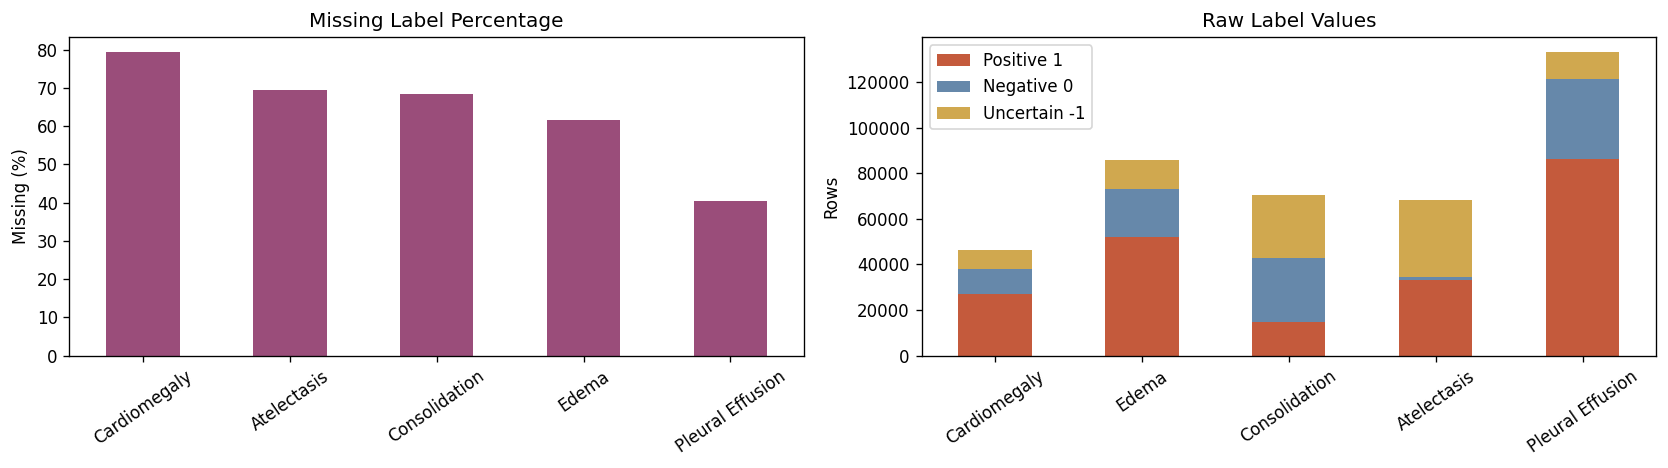

In [24]:
missing = df[LABELS].isna().sum().to_frame('missing_count')
missing['missing_percent'] = 100 * missing['missing_count'] / len(df)
display(missing.round(2))

raw_label_counts = pd.concat(
    [df[label].value_counts(dropna=False).rename(label) for label in LABELS],
    axis=1,
).fillna(0).astype(int)
display(raw_label_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
missing['missing_percent'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='#9a4d7a')
axes[0].set_title('Missing Label Percentage')
axes[0].set_ylabel('Missing (%)')
axes[0].tick_params(axis='x', rotation=35)
raw_label_counts.T[[1.0, 0.0, -1.0]].plot(kind='bar', stacked=True, ax=axes[1], color=['#c45a3c', '#6688aa', '#d0a84f'])
axes[1].set_title('Raw Label Values')
axes[1].set_ylabel('Rows')
axes[1].legend(['Positive 1', 'Negative 0', 'Uncertain -1'])
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
display(fig)
plt.close(fig)

,positive,negative,positive_rate
Pleural Effusion,76899,114128,0.4026
Edema,49675,141352,0.2600
Atelectasis,29720,161307,0.1556
Cardiomegaly,23385,167642,0.1224
Consolidation,12983,178044,0.0680


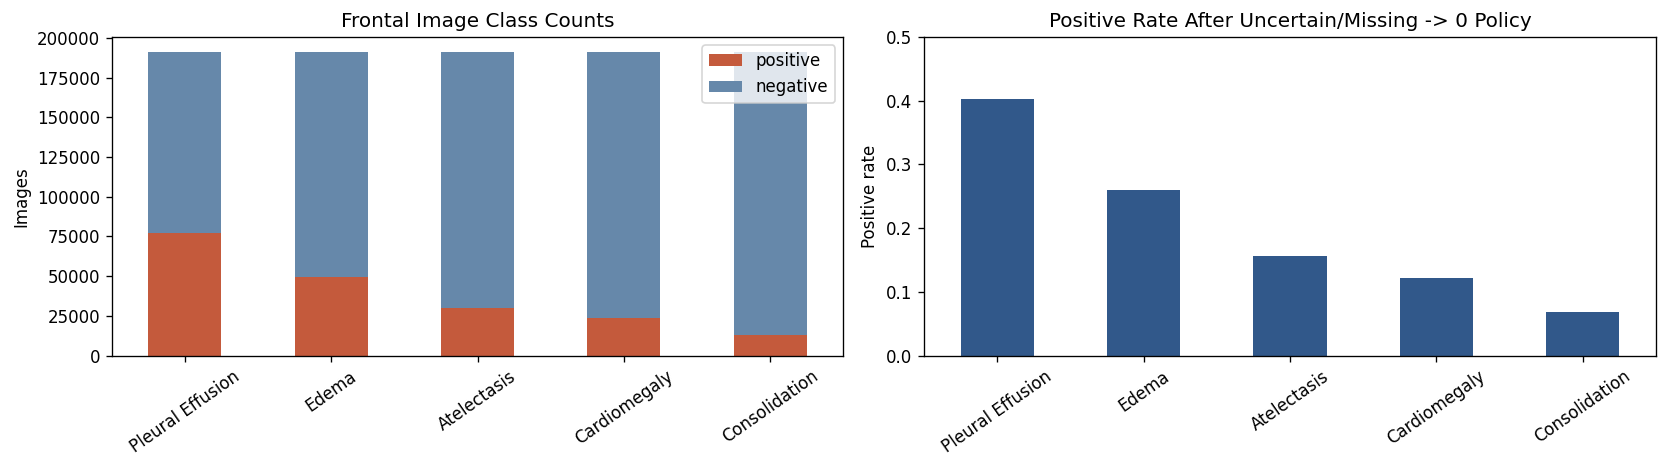

In [25]:
frontal = df[df['Frontal/Lateral'] == 'Frontal'].copy()
binary = frontal[LABELS].replace(-1, 0).fillna(0).astype(int)
class_balance = pd.DataFrame({
    'positive': binary.sum(),
    'negative': (binary == 0).sum(),
    'positive_rate': binary.mean(),
}).sort_values('positive_rate', ascending=False)
display(class_balance.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
class_balance[['positive', 'negative']].plot(kind='bar', stacked=True, ax=axes[0], color=['#c45a3c', '#6688aa'])
axes[0].set_title('Frontal Image Class Counts')
axes[0].set_ylabel('Images')
axes[0].tick_params(axis='x', rotation=35)
ax = class_balance['positive_rate'].plot(kind='bar', ax=axes[1], color='#31588a')
ax.set_title('Positive Rate After Uncertain/Missing -> 0 Policy')
axes[1].set_ylabel('Positive rate')
axes[1].set_ylim(0, 0.5)
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
display(fig)
plt.close(fig)

## Label Co-occurrence Diagram

Because CheXpert is multi-label, the same image can have several findings. The heatmap below shows how often the selected labels appear together after the initial uncertainty/missing-value policy.

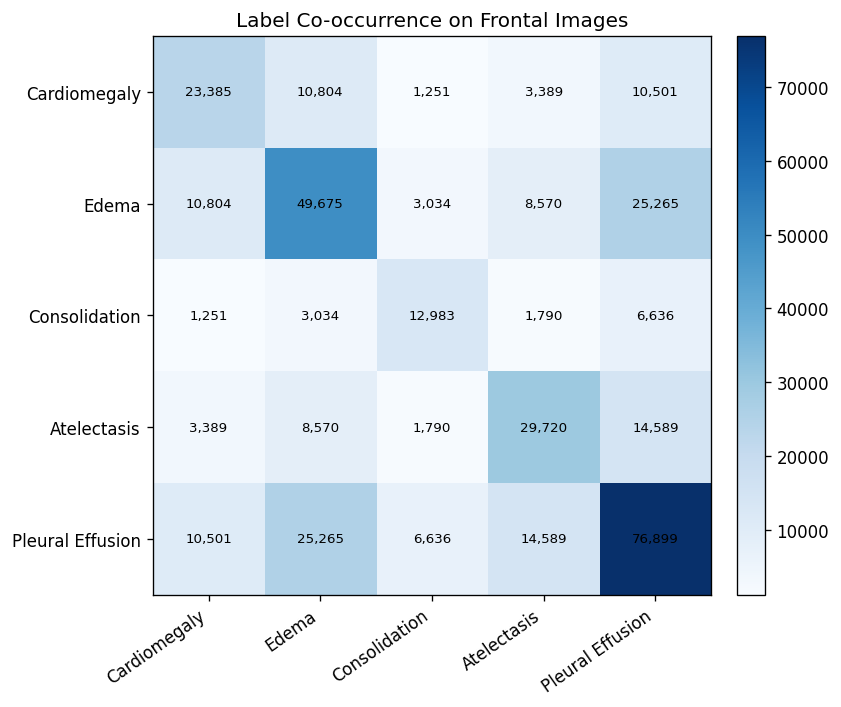

In [26]:
co_occurrence = binary.T @ binary
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(co_occurrence, cmap='Blues')
ax.set_xticks(range(len(LABELS)))
ax.set_yticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=35, ha='right')
ax.set_yticklabels(LABELS)
ax.set_title('Label Co-occurrence on Frontal Images')
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, f'{co_occurrence.iloc[i, j]:,}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
display(fig)
plt.close(fig)

## Image Path Check and Examples

In [27]:
paths = df['Path'].map(lambda rel_path: RAW_DIR / rel_path)
path_check = pd.Series([p.exists() for p in paths])
print(f'Existing image rows: {path_check.sum():,} / {len(path_check):,}')
print(f'Missing image rows: {(~path_check).sum():,}')

Existing image rows: 223,414 / 223,414
Missing image rows: 0


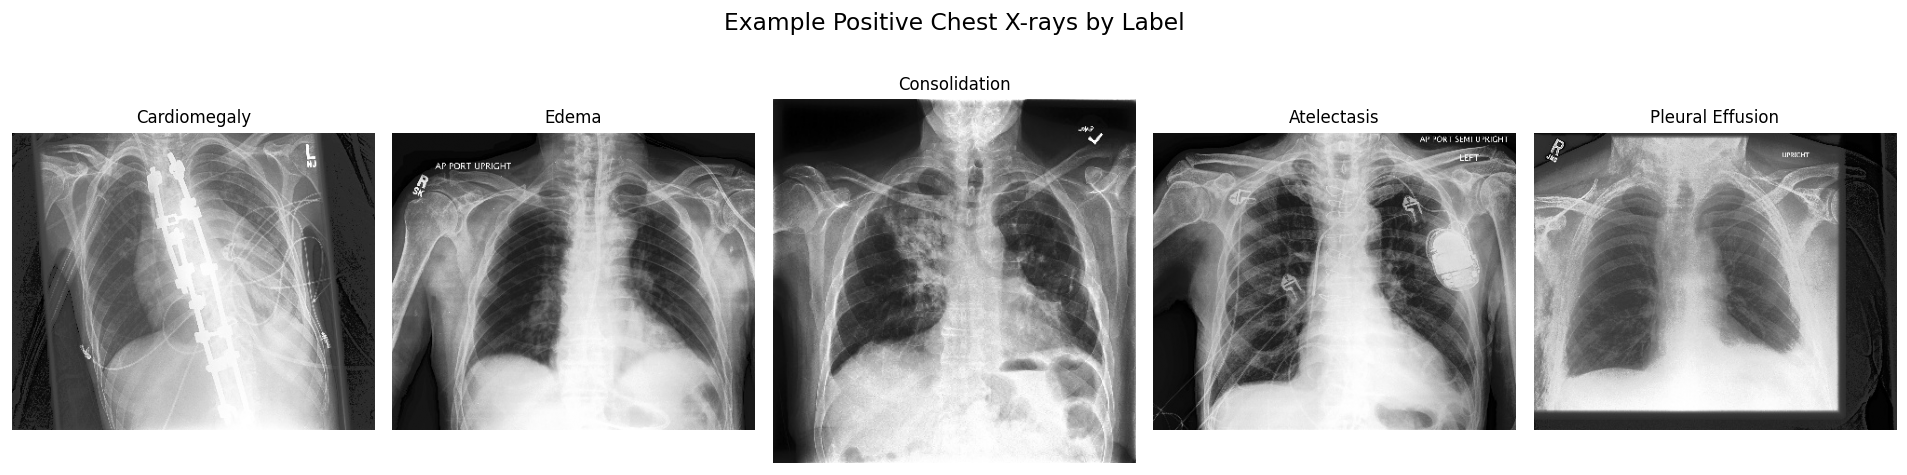

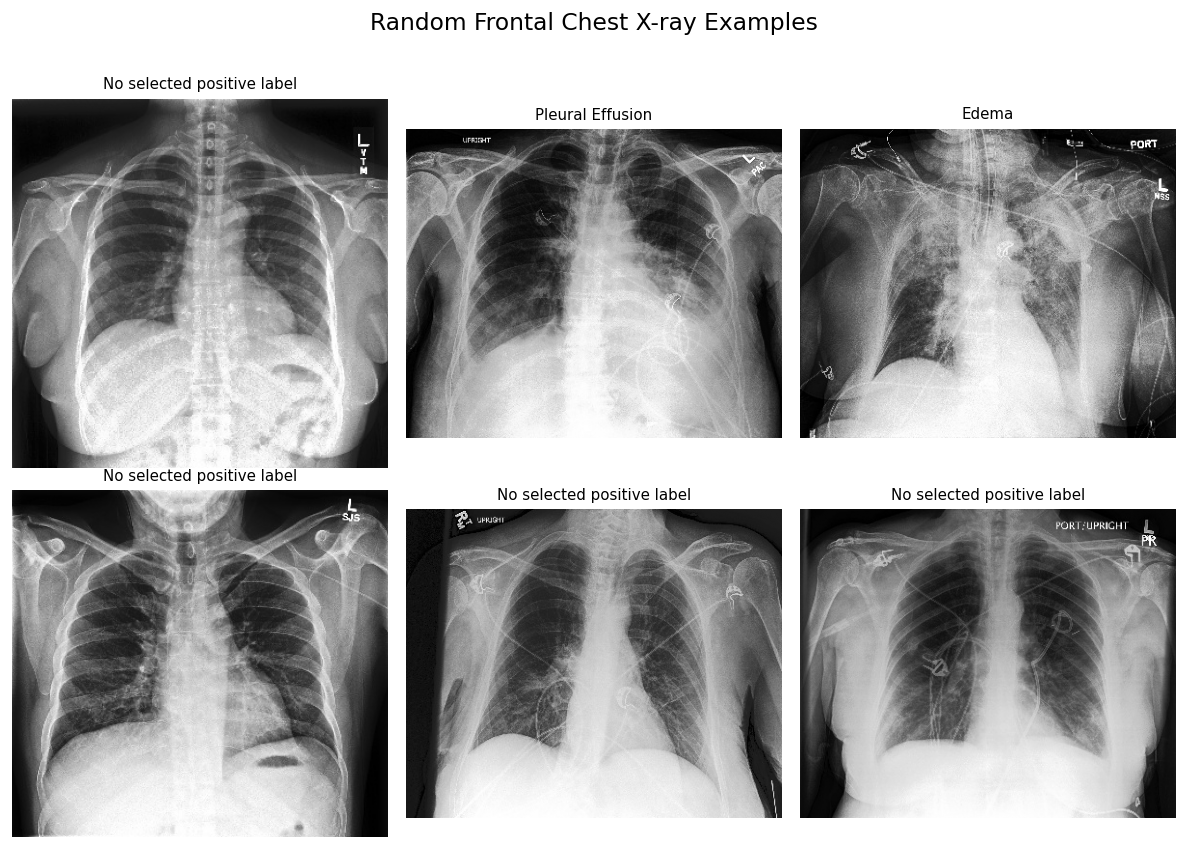

In [28]:
examples = []
for label in LABELS:
    rows = frontal[frontal[label] == 1]
    if len(rows):
        examples.append((label, rows.sample(1, random_state=42).iloc[0]))

fig, axes = plt.subplots(1, len(examples), figsize=(16, 4))
for ax, (label, row) in zip(axes, examples):
    image = Image.open(RAW_DIR / row['Path']).convert('L')
    ax.imshow(image, cmap='gray')
    ax.set_title(label, fontsize=10)
    ax.axis('off')
fig.suptitle('Example Positive Chest X-rays by Label', y=1.02, fontsize=14)
plt.tight_layout()
display(fig)
plt.close(fig)

random_examples = frontal.sample(6, random_state=7).reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for ax, (_, row) in zip(axes.ravel(), random_examples.iterrows()):
    image = Image.open(RAW_DIR / row['Path']).convert('L')
    ax.imshow(image, cmap='gray')
    positive_labels = [label for label in LABELS if row[label] == 1]
    title = ', '.join(positive_labels) if positive_labels else 'No selected positive label'
    ax.set_title(title, fontsize=9)
    ax.axis('off')
fig.suptitle('Random Frontal Chest X-ray Examples', y=1.02, fontsize=14)
plt.tight_layout()
display(fig)
plt.close(fig)

## Preprocessing Required

Required preprocessing for Week 2 and later FL experiments:

- Keep frontal images only to reduce view heterogeneity.
- Extract patient IDs from image paths and split by patient to avoid leakage.
- Convert uncertain `-1` and missing labels to `0` for the initial baseline.
- Resize images to a fixed size, usually 224x224 for CNNs or 32x32/64x64 for fast sanity checks.
- Normalize image tensors with ImageNet statistics when using a pretrained CNN feature extractor.
- Track class imbalance because positive rates range widely across labels.